#***XGboost***

This notebook trains and evaluates a XGBoost model for underwater acoustic classification.

Evaluation metrics:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix


**Like random forest, xgboost is also a tree based model and doesnt require scaled data**

In [1]:
!pip install xgboost

Import libraries:

In [2]:
import pandas as pd
import numpy as np

from pathlib import Path

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

import joblib

Mount Drive:

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Define Path:

In [4]:
PROJECT_DIR = Path("/content/drive/MyDrive/Underwater Audio Data")

DATA_DIR = PROJECT_DIR / "splits"                   #Here we use the data before scaling, because randomforest doesnt require scaling.

MODEL_DIR = PROJECT_DIR / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

Load Data:

In [5]:
X_train = pd.read_csv(DATA_DIR / "X_train.csv")                         #Unscaled features used

X_test = pd.read_csv(DATA_DIR / "X_test.csv")                           #unscaled features used

y_train = pd.read_csv(DATA_DIR / "y_train.csv")

y_test = pd.read_csv(DATA_DIR / "y_test.csv")

Converts labels to series:

In [6]:
y_train = y_train.squeeze()

y_test = y_test.squeeze()

Label Encoders

In [7]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

Verify Shape:

In [8]:
print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print()

print("Training Labels :", y_train.shape)

print("Testing Labels :", y_test.shape)

Training Features : (6086, 155)
Testing Features : (1811, 155)

Training Labels : (6086,)
Testing Labels : (1811,)


Create the model:

In [9]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softmax",
    eval_metric="mlogloss",
    random_state=42
)

Train the model:

In [10]:
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

Make predictions:

In [11]:
y_pred = model.predict(X_test)

Accuracy:

In [12]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8288


Precision, Recall, F1-score:

In [13]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

Precision : 0.8650
Recall    : 0.8288
F1 Score  : 0.8147


Classification Report:

In [14]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      0.39      0.56       360
           1       0.67      0.97      0.80       500
           2       0.93      0.92      0.92       951

    accuracy                           0.83      1811
   macro avg       0.86      0.76      0.76      1811
weighted avg       0.86      0.83      0.81      1811



Confusion matrix:

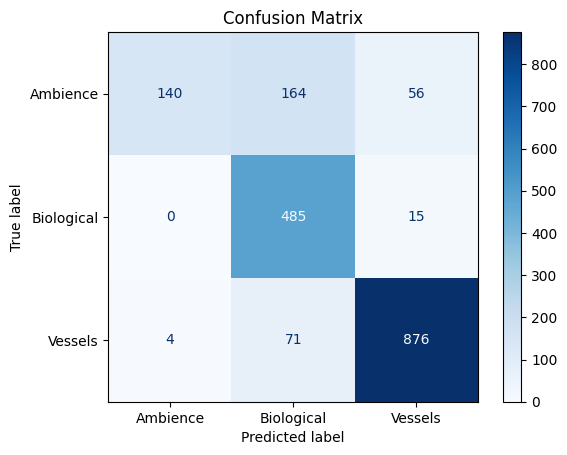

In [15]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

Saave the model:

In [16]:
joblib.dump(model, MODEL_DIR / "xgboost.pkl")

joblib.dump(label_encoder, MODEL_DIR / "label_encoder.pkl")

['/content/drive/MyDrive/Underwater Audio Data/models/label_encoder.pkl']

FINAL SUMMARY

In [17]:
print("=" * 60)

print("XGBOOST COMPLETED")

print("=" * 60)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print()

print("Model saved to:")

print(MODEL_DIR / "xgboost.pkl")

XGBOOST COMPLETED
Accuracy : 0.8288
Precision: 0.8650
Recall   : 0.8288
F1 Score : 0.8147

Model saved to:
/content/drive/MyDrive/Underwater Audio Data/models/xgboost.pkl
